# Investigating multi date experiments

The experimental pipeline that has been set up to evaluate drug responses of MPNST tumors using PDX systems has yielded a large number of tumor response data files, all stored on [Synapse](https://www.synapse.org/Synapse:syn52369030/wiki/623527).
Specifically, we have access to processed data for single agent treatment ([https://www.synapse.org/Synapse:syn65473019](https://www.synapse.org/Synapse:syn65473019)), combination agent treatment ([https://www.synapse.org/Synapse:syn66330226](https://www.synapse.org/Synapse:syn66330226)) as well as a specialized exploration in the combined effects of MEK and EGFR inhibition ([https://www.synapse.org/Synapse:syn71857386](https://www.synapse.org/Synapse:syn71857386)).

For several tumor / single agent treatment evaluations, several experiments were run at different times (not to be confused with timepoints at which tumor viability in response to the agent was measured).
The purpose of this notebook is to look into the impact and potential batch effect of experiments run at different times on the calculated AUCs (and other drug response metrics) via curve fitting.
The specific question this notebooks aims to answer is:

***Can we use the response data from all experiments during the curve fitting procedure?***

Currently, this is how the script generating the curve statistics (`00_createCurveStats.py`) handles the issue with the caveat that the initial set of experiments from Jan 22nd 2025 has been removed from consideration.
The alternative will be to rely only on one set of experiments for example the most recent batch of experiments for each combination of tumor and agent that is tested.

## Setup
Before we start this process we need to define some imports that are necessary.

In [1]:
import synapseclient as sc
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import seaborn.objects as so
# import subprocess

## Basic exploration of the experimental data

To get a better feel for how experimental setups from different dates for a given tested combination of tumor & agent are behaving we will do some basic exploration of the data. To start of we specifically look at the example of JH-2-002 treated with TNO155.

### File import

First we define the synapse ids, for the files that we are specifically interested in and import those into data frames for further investigation.

All of the experiments that are imported are:

- JH-2-002
- TNO155 treated
- Day2 Growth

Data is available for experiments from four different dates with the associated synapse ids (`synapse_ids`).
We will temporarily store all downloaded DataFrames into a dictionary (`dfs`).

In [197]:
synapse_ids = {
    '2025-01-22': 'syn65660962',
    '2025-04-01': 'syn66724858',
    '2025-04-08': 'syn66724871',
    '2025-05-13': 'syn66694987',
}

dfs = {}

Using the `synapseclient` API we login to Synapse, retrieve the four files defined using their synapse id (`syn_id`), and also addionally store the date information into the associated DataFrame into a `date` column.

In [198]:
syn = sc.login()
for date, syn_id in synapse_ids.items():
    dfs[date] = pd.read_csv(syn.get(syn_id).path)
    dfs[date]['date'] = date

syn.logout()

Welcome, ymahlich! You are using the 'default' profile.
[syn65660962:JH2002_TNO155_Day2_250122.csv]: Found existing file at /Users/mahl006/.synapseCache/439/154268439/JH2002_TNO155_Day2_250122.csv, skipping download.
[syn66724858:JH2002_TNO155_Day2_250401.csv]: Found existing file at /Users/mahl006/.synapseCache/514/156823514/JH2002_TNO155_Day2_250401.csv, skipping download.
[syn66724871:JH2002_TNO155_Day2_250408.csv]: Found existing file at /Users/mahl006/.synapseCache/540/156823540/JH2002_TNO155_Day2_250408.csv, skipping download.
[syn66694987:JH2002_TNO155_Day2_250513.csv]: Found existing file at /Users/mahl006/.synapseCache/211/156673211/JH2002_TNO155_Day2_250513.csv, skipping download.


Finally we concatenate all of the four DataFrames into one final DataFrame (`df`) that we use for the basic evaluation.

In [199]:
df = pd.concat(dfs.values())

### Investigating deviations of viability scores

Note that each date contains 3 replicates (different `specimenID`) per concentration.

Below is an example for:
- viability measure (`percentViability`)
- of replicates 1-3 (`specimenID`)
- treated with 300µM (`concentration`) of TNO155 (`drugName`)
- for experiments from (`date`)
  - 2025/01/22
  - 2025/04/01

In [5]:
df.loc[df['concentration'] == 300, ['date', 'specimenID', 'drugName', 'concentration', 'percentViability']].head(6)

,date,specimenID,drugName,concentration,percentViability
0,2025-01-22,JH2002 rep1,TNO155,300.0,16.829710
8,2025-01-22,JH2002 rep2,TNO155,300.0,17.762540
16,2025-01-22,JH2002 rep3,TNO155,300.0,14.870420
0,2025-04-01,JH2002 rep1,TNO155,300.0,6.728827
8,2025-04-01,JH2002 rep2,TNO155,300.0,5.311851
16,2025-04-01,JH2002 rep3,TNO155,300.0,8.218168


As can be seen in the `percentViability` column of the output displayed above, the delta between viability measures of replicates within a date is less than between replicates across different experiment dates.
To visualize this behaviour we will plot all viability percentages across all dates and replicates. 

#### Plotting viability scores across dates and 
The code block below plots viability scores for each concentration, grouped by date, i.e. 3 measures per date and concentration combination, one per replicate.
The x-Axis (concentration) is in logarithmic scale to better visualize the viability deviations at each individual concentration.

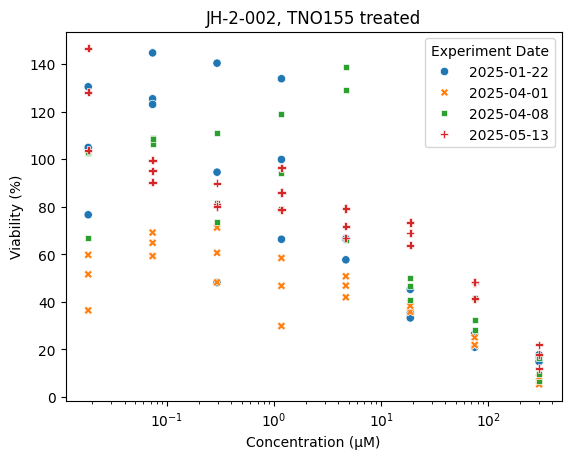

In [6]:
plot_all = sns.scatterplot(
    data=df,
    x='concentration',
    y='percentViability',
    hue='date',
    style='date',
    )

plt.xscale("log")
plt.title("JH-2-002, TNO155 treated")
plt.ylabel("Viability (%)")
plt.xlabel("Concentration (µM)")
plot_all.legend(title='Experiment Date')

As expected viability is more variable with smaller concentrations and converges with higher concentrations.
We can also see that variance within a given date (across the different replicates) is generally lower.

#### Mean viability percentages per concentration grouped by date (i.e. the mean across replicates)

To further illustrate the fact that there is a large discrepancy in reported viability for the same drug concentration across different experiment dates, we will plot the mean percentViability per concentration and date.

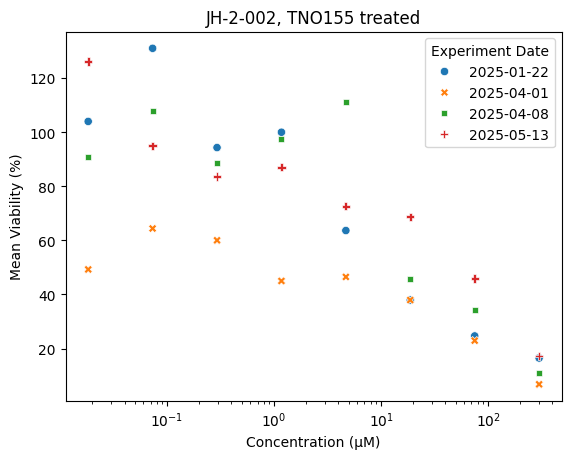

In [7]:
df_mean = (df
    .groupby(['concentration', 'date'], as_index=False)['percentViability']
    .mean()
)

plot_mean = sns.scatterplot(
    data=df_mean,
    x='concentration',
    y='percentViability',
    hue='date',
    style='date'
    )
plt.xscale("log")
plt.title("JH-2-002, TNO155 treated")
plt.ylabel("Mean Viability (%)")
plt.xlabel("Concentration (µM)")
plot_mean.legend(title='Experiment Date')

#### Standard deviation of viability percentages per concentration grouped by date (i.e. the mean across replicates)

Finally, to visualize the discrepancies of viability within a given concentration & date combination (i.e. between replicates) we plot the standard deviation of the `percentViability`.
Admittedly, given that the deviation is calculated based on only 3 values per reported standard deviation (same as with the mean viability), the power of the anlysis is limited.
Yet, it still illustrates the fact that there is a lot of variability within the data.

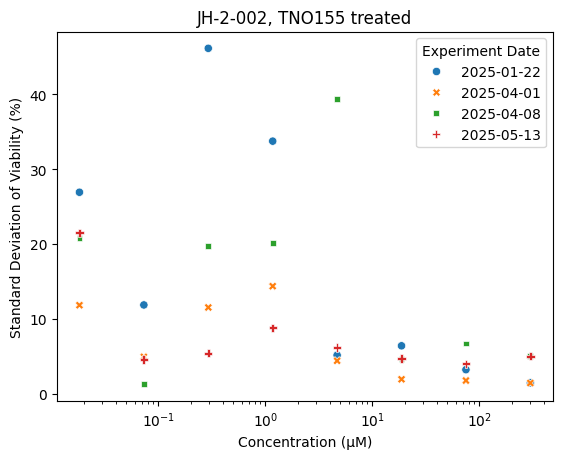

In [8]:
df_std = (df
    .groupby(['concentration', 'date'], as_index=False)['percentViability']
    .std()
)

plot_std = sns.scatterplot(
    data=df_std,
    x='concentration',
    y='percentViability',
    hue='date',
    style='date',
    )

plt.xscale("log")
plt.title("JH-2-002, TNO155 treated")
plt.ylabel("Standard Deviation of Viability (%)")
plt.xlabel("Concentration (µM)")
plot_std.legend(title='Experiment Date')

All 3 plots demonstrate that there is considerable variability of reported viability (per concentration) both across as well as within experiment dates.

#### Comparision of AUC & R^2 based on individual date data vs data from all dates

As a final evaluation specifically for the example of JH-2-002 treated with TNO155 (at the 48h mark) we will be performing the curve fitting based on individual experiment dates to retrieve drug response metrics like AUC and compare that against the drug response metrics obtained by running the curve fitting based on the combined data from all 4 dates.

To that end we first define some helper functions to preprocess the data, respectively initialize the curve fitting.

##### Helper function to fit curves

Note that this function is loosely based on functionality available in `00_createCurveStats.py` and only copied here for quicker access and additional clean up of the function.

In [193]:
from copy import deepcopy
import os
import subprocess

def fit_curves(df: pd.DataFrame, group_by_date: bool=False):

    fulltab = deepcopy(df)

    """
    The renaming of columns has to be done such that the column names
    are compatible with the prexisting curve fitting script lifted from
    coderdata.
    """
    fulltab = fulltab.rename(
        columns={
            "concentration": "DOSE",
            "percentViability": "GROWTH",
            "timePoint": "time",
            "timePointUnit": "time_unit",
            "drugName": "Drug"}
        )
    
    """
    Adding in additional columns that the curve fitting script expects
    """
    fulltab['study']='mpnstPDXMT'
    fulltab['source']='synapse'
    if group_by_date:
        fulltab['improve_sample_id'] = (
            fulltab['sampleName'].astype(str)
            + '_'
            + fulltab['date'].astype(str)
        )
    else:
        fulltab['improve_sample_id'] = fulltab['sampleName']
    
    """
    Rearranging the columns to be in the order expected by the curve
    fitting script
    """
    ncols = [
        'DOSE',
        'GROWTH',
        'study',
        'source',
        'improve_sample_id',
        'Drug',
        'time',
        'time_unit'
        ]
    fulltab = fulltab[ncols]
    
    """
    changing the values in the `GROWTH` column to numeric (i.e. making
    sure that there aren't any artefacts) and saving the DataFrame to a
    temporary file that the curve fitting script can import.
    """
    if fulltab['GROWTH'].dtype == 'object':
        if any(fulltab['GROWTH'].str.contains("\*")):
            fulltab["GROWTH"] = fulltab["GROWTH"].replace(r'\*','', regex=True)
    fulltab['GROWTH'] = pd.to_numeric(fulltab['GROWTH'])
    fulltab.to_csv('mpnst_drug_response.tsv', sep='\t')
    
    """
    Routine to run the curve fitting script. If the script is not
    available locally we will retrieve it from the coderdata git
    repository.
    Once available locally we will execute the script with the
    previously generated csv as input.
    """
    script = (
        'https://raw.githubusercontent.com/PNNL-CompBio/coderdata/'
        'refs/heads/main/coderbuild/utils/fit_curve.py'
    )
    if not os.path.exists("fit_curve.py"):
        subprocess.run(['wget', script, '-O', 'fit_curve.py'])
    
    """
    Executing the actual curve fitting
    """
    subprocess.run([
        'python', 'fit_curve.py',
        '--input', 'mpnst_drug_response.tsv',
        '--output', 'mpnstDrugOutput'
    ])

    """
    Importing the result file generated by the curve fitting script into
    a DataFrame and returning it.
    """
    otab = pd.read_csv('mpnstDrugOutput.0', sep='\t')
    return otab


[WARNING] <>:59: SyntaxWarning: invalid escape sequence '\*'

[WARNING] <>:59: SyntaxWarning: invalid escape sequence '\*'

[WARNING] /var/folders/81/d9jch6jj21z6tg8dndtgpry00000gn/T/ipykernel_71431/1008205914.py:59: SyntaxWarning: invalid escape sequence '\*'
  if any(fulltab['GROWTH'].str.contains("\*")):



#### Generation of drug response metrics

As mentioned previously the drug respones metrics (e.g. AUC & R^2) are generated using the curve fitting algorithm also employed in coderdata.
The next code block uses the helper function defined above to generate input files where individual combinations of tumor sample and tested agent are grouped by date i.e., the experiments measuring tumor viability of JH-2-002 treated with TNO155 from 2025/01/22 & 2025/04/01 are regarded as separate experiments and curve fitting is done individually for each of these.

As second prepatory step for plotting the results the `improve_sample_id` that is generated by the `fit_curves()` function which contains the date of the experiment is separated into two distinct columns recording the original `improve_sample_id` as well as the `date`.

In [200]:
df_grp_by_date_curve_fit_results = fit_curves(df, group_by_date=True)
df_grp_by_date_curve_fit_results[['improve_sample_id', 'date']] = (
    df_grp_by_date_curve_fit_results['improve_sample_id']
    .str.split('_', expand=True)
)

mkdir -p failed for path /app/tmp/matplotlib: [Errno 30] Read-only file system: '/app'
Matplotlib created a temporary cache directory at /var/folders/81/d9jch6jj21z6tg8dndtgpry00000gn/T/matplotlib-sz24swqq because there was an issue with the default path (/app/tmp/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.
Matplotlib is building the font cache; this may take a moment.


mpnst_drug_response.tsv
<bound method NDFrame.head of     Unnamed: 0      DOSE    GROWTH  ...    Drug time time_unit
0            0  3.522879  0.168297  ...  TNO155   48     hours
1            1  4.124939  0.209116  ...  TNO155   48     hours
2            2  4.726999  0.452529  ...  TNO155   48     hours
3            3  5.329059  0.667816  ...  TNO155   48     hours
4            4  5.931119  0.998713  ...  TNO155   48     hours
..         ...       ...       ...  ...     ...  ...       ...
91          19  5.329059  0.668870  ...  TNO155   48     hours
92          20  5.931119  0.859856  ...  TNO155   48     hours
93          21  6.533179  0.898658  ...  TNO155   48     hours
94          22  7.135239  0.903443  ...  TNO155   48     hours
95          23  7.737299  1.466092  ...  TNO155   48     hours

[96 rows x 9 columns]>
we have 12 cores and 11 threads


mkdir -p failed for path /app/tmp/matplotlib: [Errno 30] Read-only file system: '/app'
mkdir -p failed for path /app/tmp/matplotlib: [Errno 30] Read-only file system: '/app'
mkdir -p failed for path /app/tmp/matplotlib: [Errno 30] Read-only file system: '/app'
mkdir -p failed for path /app/tmp/matplotlib: [Errno 30] Read-only file system: '/app'
mkdir -p failed for path /app/tmp/matplotlib: [Errno 30] Read-only file system: '/app'
mkdir -p failed for path /app/tmp/matplotlib: [Errno 30] Read-only file system: '/app'
mkdir -p failed for path /app/tmp/matplotlib: [Errno 30] Read-only file system: '/app'
mkdir -p failed for path /app/tmp/matplotlib: [Errno 30] Read-only file system: '/app'
Matplotlib created a temporary cache directory at /var/folders/81/d9jch6jj21z6tg8dndtgpry00000gn/T/matplotlib-h1yom41f because there was an issue with the default path (/app/tmp/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to s

Analogous to the previous codeblock, we generate drug response metrics, however this time we do not group by date.
Instead all viability measures for a given combination of tumor sample and drug are combined into one and drug response is calculated based on the combined data.

Finally, we indicate this fact by setting the `data` to `combined`.

In [201]:
df_all_dates_curve_fit_results = fit_curves(df, False)
df_all_dates_curve_fit_results['date'] = 'combined'

mkdir -p failed for path /app/tmp/matplotlib: [Errno 30] Read-only file system: '/app'
Matplotlib created a temporary cache directory at /var/folders/81/d9jch6jj21z6tg8dndtgpry00000gn/T/matplotlib-zk5yh6bt because there was an issue with the default path (/app/tmp/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.
Matplotlib is building the font cache; this may take a moment.


mpnst_drug_response.tsv
<bound method NDFrame.head of     Unnamed: 0      DOSE    GROWTH  ...    Drug time time_unit
0            0  3.522879  0.168297  ...  TNO155   48     hours
1            1  4.124939  0.209116  ...  TNO155   48     hours
2            2  4.726999  0.452529  ...  TNO155   48     hours
3            3  5.329059  0.667816  ...  TNO155   48     hours
4            4  5.931119  0.998713  ...  TNO155   48     hours
..         ...       ...       ...  ...     ...  ...       ...
91          19  5.329059  0.668870  ...  TNO155   48     hours
92          20  5.931119  0.859856  ...  TNO155   48     hours
93          21  6.533179  0.898658  ...  TNO155   48     hours
94          22  7.135239  0.903443  ...  TNO155   48     hours
95          23  7.737299  1.466092  ...  TNO155   48     hours

[96 rows x 9 columns]>
we have 12 cores and 11 threads


mkdir -p failed for path /app/tmp/matplotlib: [Errno 30] Read-only file system: '/app'
mkdir -p failed for path /app/tmp/matplotlib: [Errno 30] Read-only file system: '/app'
mkdir -p failed for path /app/tmp/matplotlib: [Errno 30] Read-only file system: '/app'
mkdir -p failed for path /app/tmp/matplotlib: [Errno 30] Read-only file system: '/app'
mkdir -p failed for path /app/tmp/matplotlib: [Errno 30] Read-only file system: '/app'
mkdir -p failed for path /app/tmp/matplotlib: [Errno 30] Read-only file system: '/app'
Matplotlib created a temporary cache directory at /var/folders/81/d9jch6jj21z6tg8dndtgpry00000gn/T/matplotlib-i2gm_09t because there was an issue with the default path (/app/tmp/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.
Matplotlib created a temporary cache directory at /var/folders/81/d9jch6jj21z6tg8dndtgpry00000gn/T/mat

In the final step before plotting the results we combine the two generated sets of drug respones metrics.
Furthermore, we generate a view on the DataFrame that contains only `auc`, `fit_auc` & `fit_r2` values which will be used as input for the plotting function.

In [202]:
df_response = pd.concat(
    (df_grp_by_date_curve_fit_results, df_all_dates_curve_fit_results)
)

metrics = ['auc', 'fit_r2']
df_response_to_plot = df_response[
    df_response["dose_response_metric"].isin(metrics)
]

df_response_to_plot.head()

,source,improve_sample_id,improve_drug_id,study,time,time_unit,dose_response_metric,dose_response_value,date
12,synapse,JH-2-002,TNO155,mpnstPDXMT,48,hours,fit_r2,0.8564,2025-01-22
13,synapse,JH-2-002,TNO155,mpnstPDXMT,48,hours,fit_r2,0.6416,2025-04-01
14,synapse,JH-2-002,TNO155,mpnstPDXMT,48,hours,fit_r2,0.8521,2025-04-08
15,synapse,JH-2-002,TNO155,mpnstPDXMT,48,hours,fit_r2,0.9233,2025-05-13
32,synapse,JH-2-002,TNO155,mpnstPDXMT,48,hours,auc,0.6501,2025-01-22


#### Plotting the curve fitting results

Below we plot the results comparing generated the values for drug response metrics grouped by individual dates vs. a combined datasets where curve fitting was performed based on all data points.

For this example of JH-2-002 treated with TNO155 at 48h we can make several observations:

1. 2025-04-01 reperesents an outlier where calculated AUC and fitted AUC values differ significantly from the other 3 dates. Importantly the calculated R^2 value that indicates the "quality" of the curve fit is also significalty lower.
2. AUC & fitted AUC values calculated for the combined dataset dose not seem to significantly impacted by the 2025-04-01 outlier. However the calculate R^2 value for the curve fit is significantly worse at ~0.65 in comparison to >0.8 for 01-22, 04-08 & 05-13 and much closer to that of the 04-01 outlier.

This leads back to the initial question: Which datasets should we base the calculation of the drug response metrics on and does it make sense to combine all datasets into one.

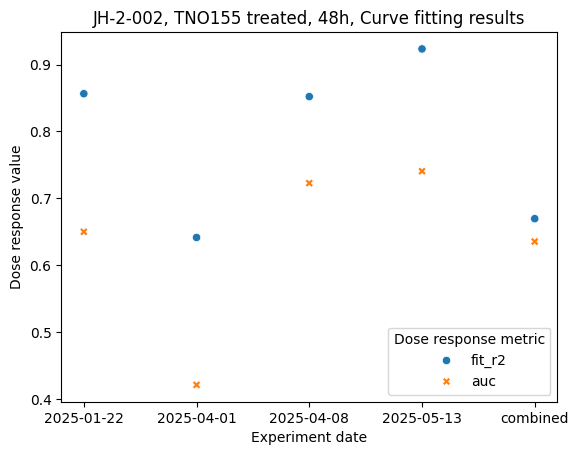

In [203]:
plot_auc = sns.scatterplot(
    data=df_response_to_plot,
    x='date',
    y='dose_response_value',
    hue="dose_response_metric",
    style='dose_response_metric'
)

plt.title("JH-2-002, TNO155 treated, 48h, Curve fitting results")
plt.ylabel("Dose response value")
plt.xlabel("Experiment date")
plot_auc.legend(title='Dose response metric')

### MN4 & TNO155 example

Welcome, ymahlich! You are using the 'default' profile.
[syn65660721:MN4_TNO155_Day2_250129.csv]: Found existing file at /Users/mahl006/.synapseCache/830/154267830/MN4_TNO155_Day2_250129.csv, skipping download.
[syn68879858:MN4_TNO155_Day2_250415.csv]: Found existing file at /Users/mahl006/.synapseCache/583/161243583/MN4_TNO155_Day2_250415.csv, skipping download.
[syn66520951:MN4_TNO155_Day2_250506.csv]: Found existing file at /Users/mahl006/.synapseCache/71/156359071/MN4_TNO155_Day2_250506.csv, skipping download.
[syn70193560:MN4_TNO155_Day2_251002.csv]: Found existing file at /Users/mahl006/.synapseCache/866/164162866/MN4_TNO155_Day2_251002.csv, skipping download.
[syn71987739:MN4_TNO155_Day2_251013.csv]: Found existing file at /Users/mahl006/.synapseCache/584/166363584/MN4_TNO155_Day2_251013.csv, skipping download.


mkdir -p failed for path /app/tmp/matplotlib: [Errno 30] Read-only file system: '/app'
Matplotlib created a temporary cache directory at /var/folders/81/d9jch6jj21z6tg8dndtgpry00000gn/T/matplotlib-696d60e9 because there was an issue with the default path (/app/tmp/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.
Matplotlib is building the font cache; this may take a moment.


mpnst_drug_response.tsv
<bound method NDFrame.head of      Unnamed: 0      DOSE    GROWTH  ...    Drug  time time_unit
0             0  3.522879 -0.005443  ...  TNO155  48.0     hours
1             1  4.124939  0.212614  ...  TNO155  48.0     hours
2             2  4.726999  0.496819  ...  TNO155  48.0     hours
3             3  5.329059  0.459514  ...  TNO155  48.0     hours
4             4  5.931119  0.972880  ...  TNO155  48.0     hours
..          ...       ...       ...  ...     ...   ...       ...
116          19  5.329059  0.344861  ...  TNO155  48.0     hours
117          20  5.931119  0.425622  ...  TNO155  48.0     hours
118          21  6.533179  0.592635  ...  TNO155  48.0     hours
119          22  7.135239  0.636348  ...  TNO155  48.0     hours
120          23  7.737299  0.575311  ...  TNO155  48.0     hours

[120 rows x 9 columns]>
we have 12 cores and 11 threads


mkdir -p failed for path /app/tmp/matplotlib: [Errno 30] Read-only file system: '/app'
mkdir -p failed for path /app/tmp/matplotlib: [Errno 30] Read-only file system: '/app'
mkdir -p failed for path /app/tmp/matplotlib: [Errno 30] Read-only file system: '/app'
mkdir -p failed for path /app/tmp/matplotlib: [Errno 30] Read-only file system: '/app'
mkdir -p failed for path /app/tmp/matplotlib: [Errno 30] Read-only file system: '/app'
mkdir -p failed for path /app/tmp/matplotlib: [Errno 30] Read-only file system: '/app'
mkdir -p failed for path /app/tmp/matplotlib: [Errno 30] Read-only file system: '/app'
mkdir -p failed for path /app/tmp/matplotlib: [Errno 30] Read-only file system: '/app'
Matplotlib created a temporary cache directory at /var/folders/81/d9jch6jj21z6tg8dndtgpry00000gn/T/matplotlib-_rka2wik because there was an issue with the default path (/app/tmp/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to s

mpnst_drug_response.tsv
<bound method NDFrame.head of      Unnamed: 0      DOSE    GROWTH  ...    Drug  time time_unit
0             0  3.522879 -0.005443  ...  TNO155  48.0     hours
1             1  4.124939  0.212614  ...  TNO155  48.0     hours
2             2  4.726999  0.496819  ...  TNO155  48.0     hours
3             3  5.329059  0.459514  ...  TNO155  48.0     hours
4             4  5.931119  0.972880  ...  TNO155  48.0     hours
..          ...       ...       ...  ...     ...   ...       ...
116          19  5.329059  0.344861  ...  TNO155  48.0     hours
117          20  5.931119  0.425622  ...  TNO155  48.0     hours
118          21  6.533179  0.592635  ...  TNO155  48.0     hours
119          22  7.135239  0.636348  ...  TNO155  48.0     hours
120          23  7.737299  0.575311  ...  TNO155  48.0     hours

[120 rows x 9 columns]>
we have 12 cores and 11 threads


mkdir -p failed for path /app/tmp/matplotlib: [Errno 30] Read-only file system: '/app'
mkdir -p failed for path /app/tmp/matplotlib: [Errno 30] Read-only file system: '/app'
mkdir -p failed for path /app/tmp/matplotlib: [Errno 30] Read-only file system: '/app'
mkdir -p failed for path /app/tmp/matplotlib: [Errno 30] Read-only file system: '/app'
mkdir -p failed for path /app/tmp/matplotlib: [Errno 30] Read-only file system: '/app'
mkdir -p failed for path /app/tmp/matplotlib: [Errno 30] Read-only file system: '/app'
mkdir -p failed for path /app/tmp/matplotlib: [Errno 30] Read-only file system: '/app'
Matplotlib created a temporary cache directory at /var/folders/81/d9jch6jj21z6tg8dndtgpry00000gn/T/matplotlib-ljlx1_5t because there was an issue with the default path (/app/tmp/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.
Matplotlib crea

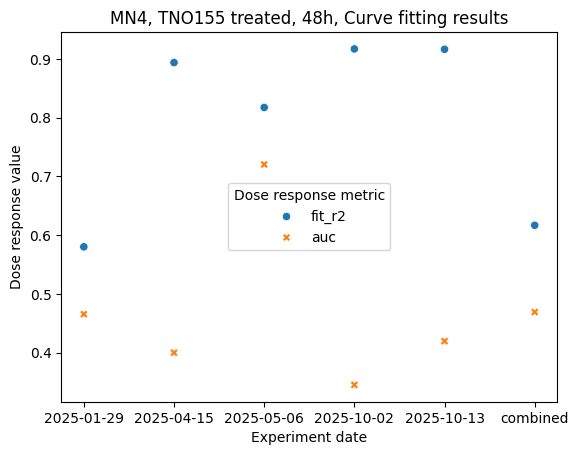

In [196]:
synapse_ids = {
    '2025-01-29': 'syn65660721',
    '2025-04-15': 'syn68879858',
    '2025-05-06': 'syn66520951',
    '2025-10-02': 'syn70193560',
    '2025-10-13': 'syn71987739'
}

dfs = {}

syn = sc.login()
for date, syn_id in synapse_ids.items():
    dfs[date] = pd.read_csv(syn.get(syn_id).path)
    dfs[date]['date'] = date

syn.logout()

df = pd.concat(dfs.values())
df.head()

df.dtypes

df_grp_by_date_curve_fit_results = fit_curves(df, group_by_date=True)
df_grp_by_date_curve_fit_results[['improve_sample_id', 'date']] = (
    df_grp_by_date_curve_fit_results['improve_sample_id']
    .str.split('_', expand=True)
)

df_all_dates_curve_fit_results = fit_curves(df, False)
df_all_dates_curve_fit_results['date'] = 'combined'

df_response = pd.concat(
    (df_grp_by_date_curve_fit_results, df_all_dates_curve_fit_results)
)

metrics = ['auc', 'fit_r2']
df_response_to_plot = df_response[
    df_response["dose_response_metric"].isin(metrics)
]

df_response_to_plot.head()

plot_auc = sns.scatterplot(
    data=df_response_to_plot,
    x='date',
    y='dose_response_value',
    hue="dose_response_metric",
    style='dose_response_metric'
)

plt.title("MN4, TNO155 treated, 48h, Curve fitting results")
plt.ylabel("Dose response value")
plt.xlabel("Experiment date")
plot_auc.legend(title='Dose response metric')

## WU-255 & trabectedin

Welcome, ymahlich! You are using the 'default' profile.
[syn65595377:WU225_trabectedin_Day2_250224.csv]: Found existing file at /Users/mahl006/.synapseCache/171/154189171/WU225_trabectedin_Day2_250224.csv, skipping download.
[syn68156120:WU225_trabectedin_Day2_250527.csv]: Found existing file at /Users/mahl006/.synapseCache/303/158523303/WU225_trabectedin_Day2_250527.csv, skipping download.
[syn68374019:WU225_trabectedin_Day2_250609.csv]: Found existing file at /Users/mahl006/.synapseCache/784/159062784/WU225_trabectedin_Day2_250609.csv, skipping download.
[syn68790601:WU225_trabectedin_Day2_250715.csv]: Found existing file at /Users/mahl006/.synapseCache/261/160840261/WU225_trabectedin_Day2_250715.csv, skipping download.


mkdir -p failed for path /app/tmp/matplotlib: [Errno 30] Read-only file system: '/app'
Matplotlib created a temporary cache directory at /var/folders/81/d9jch6jj21z6tg8dndtgpry00000gn/T/matplotlib-ok3n5kg4 because there was an issue with the default path (/app/tmp/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.
Matplotlib is building the font cache; this may take a moment.


mpnst_drug_response.tsv
<bound method NDFrame.head of     Unnamed: 0       DOSE    GROWTH  ...         Drug time time_unit
0            0   6.183096  0.098721  ...  trabectedin   48     hours
1            1   6.785156  0.125792  ...  trabectedin   48     hours
2            2   7.387216  0.254188  ...  trabectedin   48     hours
3            3   7.989276  0.735265  ...  trabectedin   48     hours
4            4   8.591336  0.864553  ...  trabectedin   48     hours
..         ...        ...       ...  ...          ...  ...       ...
91          19   8.107210  1.042097  ...  trabectedin   48     hours
92          20   8.709269  1.039969  ...  trabectedin   48     hours
93          21   9.311331  1.129898  ...  trabectedin   48     hours
94          22   9.913391  1.098002  ...  trabectedin   48     hours
95          23  10.515415  1.035595  ...  trabectedin   48     hours

[96 rows x 9 columns]>
we have 12 cores and 11 threads


mkdir -p failed for path /app/tmp/matplotlib: [Errno 30] Read-only file system: '/app'
mkdir -p failed for path /app/tmp/matplotlib: [Errno 30] Read-only file system: '/app'
mkdir -p failed for path /app/tmp/matplotlib: [Errno 30] Read-only file system: '/app'
mkdir -p failed for path /app/tmp/matplotlib: [Errno 30] Read-only file system: '/app'
mkdir -p failed for path /app/tmp/matplotlib: [Errno 30] Read-only file system: '/app'
mkdir -p failed for path /app/tmp/matplotlib: [Errno 30] Read-only file system: '/app'
mkdir -p failed for path /app/tmp/matplotlib: [Errno 30] Read-only file system: '/app'
mkdir -p failed for path /app/tmp/matplotlib: [Errno 30] Read-only file system: '/app'
mkdir -p failed for path /app/tmp/matplotlib: [Errno 30] Read-only file system: '/app'
Matplotlib created a temporary cache directory at /var/folders/81/d9jch6jj21z6tg8dndtgpry00000gn/T/matplotlib-18hom2o4 because there was an issue with the default path (/app/tmp/matplotlib); it is highly recommended t

mpnst_drug_response.tsv
<bound method NDFrame.head of     Unnamed: 0       DOSE    GROWTH  ...         Drug time time_unit
0            0   6.183096  0.098721  ...  trabectedin   48     hours
1            1   6.785156  0.125792  ...  trabectedin   48     hours
2            2   7.387216  0.254188  ...  trabectedin   48     hours
3            3   7.989276  0.735265  ...  trabectedin   48     hours
4            4   8.591336  0.864553  ...  trabectedin   48     hours
..         ...        ...       ...  ...          ...  ...       ...
91          19   8.107210  1.042097  ...  trabectedin   48     hours
92          20   8.709269  1.039969  ...  trabectedin   48     hours
93          21   9.311331  1.129898  ...  trabectedin   48     hours
94          22   9.913391  1.098002  ...  trabectedin   48     hours
95          23  10.515415  1.035595  ...  trabectedin   48     hours

[96 rows x 9 columns]>
we have 12 cores and 11 threads


mkdir -p failed for path /app/tmp/matplotlib: [Errno 30] Read-only file system: '/app'
mkdir -p failed for path /app/tmp/matplotlib: [Errno 30] Read-only file system: '/app'
mkdir -p failed for path /app/tmp/matplotlib: [Errno 30] Read-only file system: '/app'
mkdir -p failed for path /app/tmp/matplotlib: [Errno 30] Read-only file system: '/app'
mkdir -p failed for path /app/tmp/matplotlib: [Errno 30] Read-only file system: '/app'
mkdir -p failed for path /app/tmp/matplotlib: [Errno 30] Read-only file system: '/app'
mkdir -p failed for path /app/tmp/matplotlib: [Errno 30] Read-only file system: '/app'
mkdir -p failed for path /app/tmp/matplotlib: [Errno 30] Read-only file system: '/app'
mkdir -p failed for path /app/tmp/matplotlib: [Errno 30] Read-only file system: '/app'
Matplotlib created a temporary cache directory at /var/folders/81/d9jch6jj21z6tg8dndtgpry00000gn/T/matplotlib-ln_yp20p because there was an issue with the default path (/app/tmp/matplotlib); it is highly recommended t

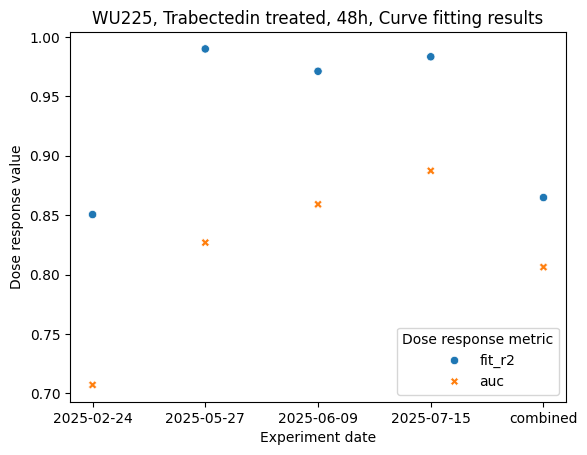

In [204]:
synapse_ids = {
    '2025-02-24': 'syn65595377',
    '2025-05-27': 'syn68156120',
    '2025-06-09': 'syn68374019',
    '2025-07-15': 'syn68790601',
}

dfs = {}

syn = sc.login()
for date, syn_id in synapse_ids.items():
    dfs[date] = pd.read_csv(syn.get(syn_id).path)
    dfs[date]['date'] = date

syn.logout()

df = pd.concat(dfs.values())
df.head()

df.dtypes

df_grp_by_date_curve_fit_results = fit_curves(df, group_by_date=True)
df_grp_by_date_curve_fit_results[['improve_sample_id', 'date']] = (
    df_grp_by_date_curve_fit_results['improve_sample_id']
    .str.split('_', expand=True)
)

df_all_dates_curve_fit_results = fit_curves(df, False)
df_all_dates_curve_fit_results['date'] = 'combined'

df_response = pd.concat(
    (df_grp_by_date_curve_fit_results, df_all_dates_curve_fit_results)
)

metrics = ['auc', 'fit_r2']
df_response_to_plot = df_response[
    df_response["dose_response_metric"].isin(metrics)
]

df_response_to_plot.head()

plot_auc = sns.scatterplot(
    data=df_response_to_plot,
    x='date',
    y='dose_response_value',
    hue="dose_response_metric",
    style='dose_response_metric'
)

plt.title("WU225, Trabectedin treated, 48h, Curve fitting results")
plt.ylabel("Dose response value")
plt.xlabel("Experiment date")
plot_auc.legend(title='Dose response metric')

## Investigating trends across all drug screens

In [25]:
syn = sc.login()
in_data_folder_id = 'syn65473019'
singleFiles = syn.tableQuery(f"SELECT * FROM syn52369043 where parentId='{in_data_folder_id}'")
singleFiles = singleFiles.asDataFrame()

syn.logout()

Welcome, ymahlich! You are using the 'default' profile.


[WARNING] /var/folders/81/d9jch6jj21z6tg8dndtgpry00000gn/T/ipykernel_71431/3151514259.py:3: DeprecationWarning: Call to deprecated method tableQuery. (To be removed in 5.0.0. Use the `query` functions from `synapseclient.models.Table` instead. Check the docstring for the replacement function example.) -- Deprecated since version 4.9.0.
  singleFiles = syn.tableQuery(f"SELECT * FROM syn52369043 where parentId='{in_data_folder_id}'")

Create CSV FileHandle: 100%|██████████| 724/724 [00:01<00:00, 529it/s]                   

[syn52369043]: Downloaded to /Users/mahl006/.synapseCache/855/166920855/SYNAPSE_TABLE_QUERY_166920855.csv


In [26]:
singleFiles

,id,name,description,createdOn,createdBy,etag,modifiedOn,modifiedBy,type,currentVersion,...,nf2Genotype,species,modelSystemName,cellType,sex,age,experimentalCondition,progressReportNumber,path,dataFileName
65595366_1_3e4844bb-49b1-4ad5-a95a-cce23a9dd73e,syn65595366,WU225_irinotecan_Day5_250224.csv,NaN,1742489538381,3431293,3e4844bb-49b1-4ad5-a95a-cce23a9dd73e,1760469404893,3431293,file,1,...,NaN,Homo sapiens,NF1,NaN,Male,38,NaN,NaN,Leveraging a Precision Medicine Platform to Pr...,WU225_irinotecan_Day5_250224.csv
65595367_1_74297ed8-ed36-4a34-acf5-912d5f9b3293,syn65595367,WU225_capmatinib_Day5_250224.csv,NaN,1742489538391,3431293,74297ed8-ed36-4a34-acf5-912d5f9b3293,1760469398341,3431293,file,1,...,NaN,Homo sapiens,NF1,NaN,Male,38,NaN,NaN,Leveraging a Precision Medicine Platform to Pr...,WU225_capmatinib_Day5_250224.csv
65595368_1_ee02378f-beeb-4978-9473-927d98ac9454,syn65595368,WU225_doxorubicin_Day5_250224.csv,NaN,1742489538404,3431293,ee02378f-beeb-4978-9473-927d98ac9454,1760469396871,3431293,file,1,...,NaN,Homo sapiens,NF1,NaN,Male,38,NaN,NaN,Leveraging a Precision Medicine Platform to Pr...,WU225_doxorubicin_Day5_250224.csv
65595369_1_3eb2963c-777c-464c-a7f1-78ae5501e421,syn65595369,WU225_doxorubicin_Day2_250224.csv,NaN,1742489538418,3431293,3eb2963c-777c-464c-a7f1-78ae5501e421,1760469398801,3431293,file,1,...,NaN,Homo sapiens,NF1,NaN,Male,38,NaN,NaN,Leveraging a Precision Medicine Platform to Pr...,WU225_doxorubicin_Day2_250224.csv
65595370_1_66c4396a-add5-408a-b0cd-b435398a159d,syn65595370,WU225_ifosfamide_Day5_250224.csv,NaN,1742489538451,3431293,66c4396a-add5-408a-b0cd-b435398a159d,1760469397436,3431293,file,1,...,NaN,Homo sapiens,NF1,NaN,Male,38,NaN,NaN,Leveraging a Precision Medicine Platform to Pr...,WU225_ifosfamide_Day5_250224.csv
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
71987836_1_fdc56f22-b7ed-4688-a65b-76c9eefbeb77,syn71987836,JH2079c_trabectedin_Day2_251209.csv,NaN,1765838323698,3431293,fdc56f22-b7ed-4688-a65b-76c9eefbeb77,1766340118893,3421893,file,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Leveraging a Precision Medicine Platform to Pr...,JH2079c_trabectedin_Day2_251209.csv
71987838_1_2fce37dc-82f4-4fc3-82d2-b73c13204f90,syn71987838,JH2079c_trametinib_Day2_251209.csv,NaN,1765838324430,3431293,2fce37dc-82f4-4fc3-82d2-b73c13204f90,1766340118963,3421893,file,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Leveraging a Precision Medicine Platform to Pr...,JH2079c_trametinib_Day2_251209.csv
71987839_1_7ef49ed1-91fa-45cb-862c-090dd5d12362,syn71987839,JH2079c_trametinib_Day5_251209.csv,NaN,1765838324532,3431293,7ef49ed1-91fa-45cb-862c-090dd5d12362,1766340119040,3421893,file,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Leveraging a Precision Medicine Platform to Pr...,JH2079c_trametinib_Day5_251209.csv
71987840_1_6ecc9984-0dfb-4f27-9c95-ae3a7b755794,syn71987840,JH2079c_selumetinib_Day2_251209.csv,NaN,1765838324631,3431293,6ecc9984-0dfb-4f27-9c95-ae3a7b755794,1766340119111,3421893,file,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Leveraging a Precision Medicine Platform to Pr...,JH2079c_selumetinib_Day2_251209.csv


In [68]:
def import_all_data_files(df_files: pd.DataFrame):

    multi_dose_experiments = []
    single_dose_experiments = []
    
    syn = sc.login(silent=True)
    for index,row in df_files.iterrows():
        dfile_raw = pd.read_csv(syn.get(row['id']).path)
        dfile = dfile_raw.drop(dfile_raw.index[dfile_raw.isna().all(axis=1)])
        if all(dfile['dataSubtype'] == 'processed'):
            date_raw = str(row['name']).rsplit(sep='_', maxsplit=1)[1][:6]
            date = f"20{date_raw[:2]}-{date_raw[2:4]}-{date_raw[4:]}"
            dfile['date'] = date
            if pd.isna(row['specimenID']):
                dfile['improve_sample_id'] = dfile['sampleName']
            else:
                dfile['improve_sample_id'] = row['specimenID']
            dfile = dfile.reset_index()
            
            ##get counts of drugs to only keep drugs with >1 dose for curve fitting
            if "drugName" in dfile.columns:
                dcounts = dfile.groupby("drugName").count().reset_index()
                #print(dcounts)
                if any(dcounts['concentration']>1):
                    #print("multi")
                    more = dcounts[dcounts['concentration']>1]['drugName']
                    #print(list(set(more)))
                    tempMulti = dfile[dfile['drugName'].isin(list(set(more)))]
                    #print(tempMulti)
                    multi_dose_experiments.append(tempMulti)
                    #print(len(multi_dose_experiments))
                
                ## also get single data points
                if any(dcounts['concentration']==1):
                    #print("single")
                    sings = dcounts[dcounts['concentration']==1]['drugName']
                    #print(list(set(sings)))
                    tempSingle = dfile[dfile['drugName'].isin(list(set(sings)))]
                    #print(tempSingle)
                    single_dose_experiments.append(tempSingle)
                    #print(len(single_dose_experiments))
    
    syn.logout()

    return (multi_dose_experiments, single_dose_experiments)

In [69]:
%%capture
multi_dose_experiments, single_dose_experiments = import_all_data_files(singleFiles)

[syn65595366:WU225_irinotecan_Day5_250224.csv]: Found existing file at /Users/mahl006/.synapseCache/157/154189157/WU225_irinotecan_Day5_250224.csv, skipping download.
[syn65595367:WU225_capmatinib_Day5_250224.csv]: Found existing file at /Users/mahl006/.synapseCache/158/154189158/WU225_capmatinib_Day5_250224.csv, skipping download.
[syn65595368:WU225_doxorubicin_Day5_250224.csv]: Found existing file at /Users/mahl006/.synapseCache/159/154189159/WU225_doxorubicin_Day5_250224.csv, skipping download.
[syn65595369:WU225_doxorubicin_Day2_250224.csv]: Found existing file at /Users/mahl006/.synapseCache/160/154189160/WU225_doxorubicin_Day2_250224.csv, skipping download.
[syn65595370:WU225_ifosfamide_Day5_250224.csv]: Found existing file at /Users/mahl006/.synapseCache/162/154189162/WU225_ifosfamide_Day5_250224.csv, skipping download.
[syn65595371:WU225_ifosfamide_Day2_250224.csv]: Found existing file at /Users/mahl006/.synapseCache/161/154189161/WU225_ifosfamide_Day2_250224.csv, skipping down

In [139]:
df = pd.concat(multi_dose_experiments)

df_all_exp_grp_by_date_curve_fit_results = fit_curves(df, group_by_date=True)
df_all_exp_grp_by_date_curve_fit_results[['improve_sample_id', 'date']] = (
    df_all_exp_grp_by_date_curve_fit_results['improve_sample_id']
    .str.split('_', expand=True)
)

mkdir -p failed for path /app/tmp/matplotlib: [Errno 30] Read-only file system: '/app'
Matplotlib created a temporary cache directory at /var/folders/81/d9jch6jj21z6tg8dndtgpry00000gn/T/matplotlib-w9ejxjkd because there was an issue with the default path (/app/tmp/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.
Matplotlib is building the font cache; this may take a moment.


mpnst_drug_response.tsv
<bound method NDFrame.head of       Unnamed: 0      DOSE    GROWTH  ...        Drug   time time_unit
0              0  3.301030 -0.008284  ...  irinotecan  120.0     hours
1              1  3.903090  0.023270  ...  irinotecan  120.0     hours
2              2  4.505150  0.122131  ...  irinotecan  120.0     hours
3              3  5.107210  0.322466  ...  irinotecan  120.0     hours
4              4  5.709270  0.659522  ...  irinotecan  120.0     hours
...          ...       ...       ...  ...         ...    ...       ...
8683          19  5.329059  0.603462  ...      TNO155   48.0     hours
8684          20  5.931119  0.306535  ...      TNO155   48.0     hours
8685          21  6.533179  0.668426  ...      TNO155   48.0     hours
8686          22  7.135239  0.725642  ...      TNO155   48.0     hours
8687          23  7.737299  0.644588  ...      TNO155   48.0     hours

[8688 rows x 9 columns]>
we have 12 cores and 11 threads


mkdir -p failed for path /app/tmp/matplotlib: [Errno 30] Read-only file system: '/app'
mkdir -p failed for path /app/tmp/matplotlib: [Errno 30] Read-only file system: '/app'
mkdir -p failed for path /app/tmp/matplotlib: [Errno 30] Read-only file system: '/app'
mkdir -p failed for path /app/tmp/matplotlib: [Errno 30] Read-only file system: '/app'
mkdir -p failed for path /app/tmp/matplotlib: [Errno 30] Read-only file system: '/app'
mkdir -p failed for path /app/tmp/matplotlib: [Errno 30] Read-only file system: '/app'
mkdir -p failed for path /app/tmp/matplotlib: [Errno 30] Read-only file system: '/app'
mkdir -p failed for path /app/tmp/matplotlib: [Errno 30] Read-only file system: '/app'
mkdir -p failed for path /app/tmp/matplotlib: [Errno 30] Read-only file system: '/app'
mkdir -p failed for path /app/tmp/matplotlib: [Errno 30] Read-only file system: '/app'
mkdir -p failed for path /app/tmp/matplotlib: [Errno 30] Read-only file system: '/app'
Matplotlib created a temporary cache direct

In [87]:
df_all_exp_joint_curve_fit_results = fit_curves(df, group_by_date=False)
df_all_exp_joint_curve_fit_results['date'] = 'joint_fit'

mkdir -p failed for path /app/tmp/matplotlib: [Errno 30] Read-only file system: '/app'
Matplotlib created a temporary cache directory at /var/folders/81/d9jch6jj21z6tg8dndtgpry00000gn/T/matplotlib-spoybr6s because there was an issue with the default path (/app/tmp/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.
Matplotlib is building the font cache; this may take a moment.


mpnst_drug_response.tsv
<bound method NDFrame.head of       Unnamed: 0      DOSE    GROWTH  ...        Drug   time time_unit
0              0  3.301030 -0.008284  ...  irinotecan  120.0     hours
1              1  3.903090  0.023270  ...  irinotecan  120.0     hours
2              2  4.505150  0.122131  ...  irinotecan  120.0     hours
3              3  5.107210  0.322466  ...  irinotecan  120.0     hours
4              4  5.709270  0.659522  ...  irinotecan  120.0     hours
...          ...       ...       ...  ...         ...    ...       ...
8683          19  5.329059  0.603462  ...      TNO155   48.0     hours
8684          20  5.931119  0.306535  ...      TNO155   48.0     hours
8685          21  6.533179  0.668426  ...      TNO155   48.0     hours
8686          22  7.135239  0.725642  ...      TNO155   48.0     hours
8687          23  7.737299  0.644588  ...      TNO155   48.0     hours

[8688 rows x 9 columns]>
we have 12 cores and 11 threads


mkdir -p failed for path /app/tmp/matplotlib: [Errno 30] Read-only file system: '/app'
mkdir -p failed for path /app/tmp/matplotlib: [Errno 30] Read-only file system: '/app'
mkdir -p failed for path /app/tmp/matplotlib: [Errno 30] Read-only file system: '/app'
mkdir -p failed for path /app/tmp/matplotlib: [Errno 30] Read-only file system: '/app'
mkdir -p failed for path /app/tmp/matplotlib: [Errno 30] Read-only file system: '/app'
mkdir -p failed for path /app/tmp/matplotlib: [Errno 30] Read-only file system: '/app'
mkdir -p failed for path /app/tmp/matplotlib: [Errno 30] Read-only file system: '/app'
mkdir -p failed for path /app/tmp/matplotlib: [Errno 30] Read-only file system: '/app'
Matplotlib created a temporary cache directory at /var/folders/81/d9jch6jj21z6tg8dndtgpry00000gn/T/matplotlib-rhscbas_ because there was an issue with the default path (/app/tmp/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to s

In [90]:
df_all_exp_grp_by_date_curve_fit_results

,source,improve_sample_id,improve_drug_id,study,time,time_unit,dose_response_metric,dose_response_value,date
0,synapse,JH-2-002,RMC4630,mpnstPDXMT,48.0,hours,fit_auc,0.6547,2025-01-22
1,synapse,JH-2-002,RMC4630,mpnstPDXMT,120.0,hours,fit_auc,0.5475,2025-01-22
2,synapse,JH-2-002,TNO155,mpnstPDXMT,48.0,hours,fit_auc,0.8177,2025-01-22
3,synapse,JH-2-002,TNO155,mpnstPDXMT,120.0,hours,fit_auc,0.3807,2025-01-22
4,synapse,JH-2-002,decitabine,mpnstPDXMT,48.0,hours,fit_auc,0.8868,2025-01-22
...,...,...,...,...,...,...,...,...,...
3605,synapse,WU-356,palbociclib,mpnstPDXMT,120.0,hours,dss,0.1739,2025-09-16
3606,synapse,WU-356,trabectedin,mpnstPDXMT,48.0,hours,dss,0.2559,2025-09-16
3607,synapse,WU-356,trabectedin,mpnstPDXMT,120.0,hours,dss,0.1423,2025-09-16
3608,synapse,WU-356,vorinostat,mpnstPDXMT,48.0,hours,dss,0.0274,2025-09-16


In [95]:
df_subset = df_all_exp_grp_by_date_curve_fit_results[
    (df_all_exp_grp_by_date_curve_fit_results["time"] == 48.0)
    # (df_all_exp_grp_by_date_curve_fit_results["dose_response_metric"] == 'auc')
    ]

In [107]:
df_std = (df_subset
    .groupby(['improve_sample_id', 'improve_drug_id', 'dose_response_metric'], as_index=False)['dose_response_value']
    .std()
)

In [108]:
df_std

,improve_sample_id,improve_drug_id,dose_response_metric,dose_response_value
0,JH-2-002,RMC4630,aac,NaN
1,JH-2-002,RMC4630,auc,NaN
2,JH-2-002,RMC4630,dss,NaN
3,JH-2-002,RMC4630,fit_auc,NaN
4,JH-2-002,RMC4630,fit_ec50,NaN
...,...,...,...,...
995,WU-356,vorinostat,fit_ec50se,0.024456
996,WU-356,vorinostat,fit_einf,0.247919
997,WU-356,vorinostat,fit_hs,3.136626
998,WU-356,vorinostat,fit_ic50,3.084230


In [109]:
df_std.shape

(1000, 4)

In [110]:
df_std_clean = df_std.dropna()
df_std_clean.shape

(476, 4)

In [111]:
df_std_clean

,improve_sample_id,improve_drug_id,dose_response_metric,dose_response_value
10,JH-2-002,TNO155,aac,0.146912
11,JH-2-002,TNO155,auc,0.146912
12,JH-2-002,TNO155,dss,0.060690
13,JH-2-002,TNO155,fit_auc,0.146096
14,JH-2-002,TNO155,fit_ec50,0.881882
...,...,...,...,...
995,WU-356,vorinostat,fit_ec50se,0.024456
996,WU-356,vorinostat,fit_einf,0.247919
997,WU-356,vorinostat,fit_hs,3.136626
998,WU-356,vorinostat,fit_ic50,3.084230


In [70]:
metrics = ['auc', 'fit_r2']
df_response_to_plot = df_std_clean[
    df_std_clean["dose_response_metric"].isin(metrics)
]

Text(0, 0.5, 'SD')

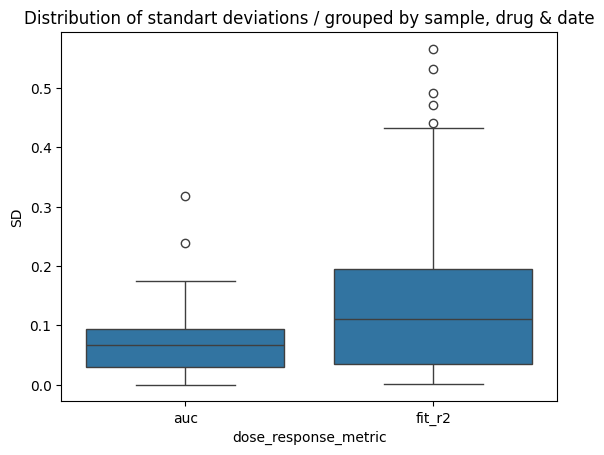

In [71]:
sns.boxplot(data=df_response_to_plot, y='dose_response_value', x='dose_response_metric')
plt.title("Distribution of standart deviations / grouped by sample, drug & date")
plt.ylabel("SD")

,improve_sample_id,improve_drug_id,dose_response_metric,dose_response_value
11,JH-2-002,TNO155,auc,0.146912
19,JH-2-002,TNO155,fit_r2,0.122259
21,JH-2-002,capmatinib,auc,0.000071
29,JH-2-002,capmatinib,fit_r2,0.054164
41,JH-2-002,doxorubicin,auc,0.096904
...,...,...,...,...
969,WU-356,palbociclib,fit_r2,0.063074
981,WU-356,trabectedin,auc,0.064559
989,WU-356,trabectedin,fit_r2,0.035355
991,WU-356,vorinostat,auc,0.064955


In [187]:
tmp = df_all_exp_grp_by_date_curve_fit_results.groupby(['improve_sample_id', 'improve_drug_id'])['study'].count()
tmp

improve_sample_id  improve_drug_id
JH-2-002           RMC4630            20
                   TNO155             80
                   capmatinib         40
                   decitabine         20
                   doxorubicin        60
                                      ..
WU-356             olaparib           40
                   palbociclib        40
                   pexidartinib       20
                   trabectedin        40
                   vorinostat         60
Name: study, Length: 100, dtype: int64

In [140]:
df_grouped_mean = (df_all_exp_grp_by_date_curve_fit_results
    .groupby(['improve_sample_id', 'improve_drug_id', 'dose_response_metric', 'time'], as_index=False)['dose_response_value']
    .mean()
)
df_grouped_mean['date'] = 'grouped_mean'
df_grouped_mean.head()

,improve_sample_id,improve_drug_id,dose_response_metric,time,dose_response_value,date
0,JH-2-002,RMC4630,aac,48.0,0.6401,grouped_mean
1,JH-2-002,RMC4630,aac,120.0,0.7843,grouped_mean
2,JH-2-002,RMC4630,auc,48.0,0.3599,grouped_mean
3,JH-2-002,RMC4630,auc,120.0,0.2157,grouped_mean
4,JH-2-002,RMC4630,dss,48.0,-0.0162,grouped_mean


In [123]:
df_joint_fit = df_all_exp_joint_curve_fit_results[['improve_sample_id', 'improve_drug_id', 'dose_response_metric', 'dose_response_value', 'date' , 'time']]
df_joint_fit.head()

,improve_sample_id,improve_drug_id,dose_response_metric,dose_response_value,date,time
0,JH-2-002,RMC4630,fit_auc,0.6547,joint_fit,48.0
1,JH-2-002,RMC4630,fit_auc,0.5475,joint_fit,120.0
2,JH-2-002,TNO155,fit_auc,0.7951,joint_fit,48.0
3,JH-2-002,TNO155,fit_auc,0.5155,joint_fit,120.0
4,JH-2-002,capmatinib,fit_auc,0.9072,joint_fit,48.0


In [124]:
df_individual_fit = df_all_exp_grp_by_date_curve_fit_results[['improve_sample_id', 'improve_drug_id', 'dose_response_metric', 'dose_response_value', 'date', 'time']]
df_individual_fit.head()

,improve_sample_id,improve_drug_id,dose_response_metric,dose_response_value,date,time
0,JH-2-002,RMC4630,fit_auc,0.6547,2025-01-22,48.0
1,JH-2-002,RMC4630,fit_auc,0.5475,2025-01-22,120.0
2,JH-2-002,TNO155,fit_auc,0.8177,2025-01-22,48.0
3,JH-2-002,TNO155,fit_auc,0.3807,2025-01-22,120.0
4,JH-2-002,decitabine,fit_auc,0.8868,2025-01-22,48.0


In [ ]:
df_joint_plot = pd.concat((
    df_grouped_mean,
    df_joint_fit,
    df_individual_fit
))
df_joint_plot.shape


df_joint_plot = df_joint_plot.pivot(
        index=['improve_sample_id', 'improve_drug_id', 'date' , 'time'],
        columns='dose_response_metric',
        values='dose_response_value'
    ).reset_index().rename_axis(None, axis=1)
df_joint_plot = (df_joint_plot[
    (df_joint_plot['date'].isin(['joint_fit','grouped_mean']))
    ])


In [142]:
df_joint_plot

,improve_sample_id,improve_drug_id,date,time,aac,auc,dss,fit_auc,fit_ec50,fit_ec50se,fit_einf,fit_hs,fit_ic50,fit_r2
2,JH-2-002,RMC4630,grouped_mean,48.0,0.640100,0.359900,-0.016200,0.654700,5.920000,0.242300,0.000000,0.3930,5.920000,0.910300
3,JH-2-002,RMC4630,grouped_mean,120.0,0.784300,0.215700,-0.054200,0.547500,6.693000,0.149700,0.000000,0.4806,6.693000,0.864400
4,JH-2-002,RMC4630,joint_fit,48.0,0.640100,0.359900,-0.016200,0.654700,5.920000,0.242300,0.000000,0.3930,5.920000,0.910300
5,JH-2-002,RMC4630,joint_fit,120.0,0.784300,0.215700,-0.054200,0.547500,6.693000,0.149700,0.000000,0.4806,6.693000,0.864400
14,JH-2-002,TNO155,grouped_mean,48.0,0.366300,0.633700,0.089575,0.780425,5.114750,0.769100,0.021625,0.5490,5.085000,0.818350
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
748,WU-356,trabectedin,joint_fit,120.0,0.381000,0.619000,0.102800,0.349200,7.905000,0.107400,0.000000,1.3930,7.905000,0.800400
755,WU-356,vorinostat,grouped_mean,48.0,0.521033,0.478967,0.172867,0.644867,3.789967,0.028067,0.189533,-0.3750,3.871067,0.653733
756,WU-356,vorinostat,grouped_mean,120.0,0.657967,0.342033,-0.004100,0.633333,6.197000,0.102700,0.000000,1.3595,6.197000,0.893733
757,WU-356,vorinostat,joint_fit,48.0,0.518600,0.481400,0.053300,0.732100,5.671000,0.033600,0.038500,1.5680,5.649000,0.958600


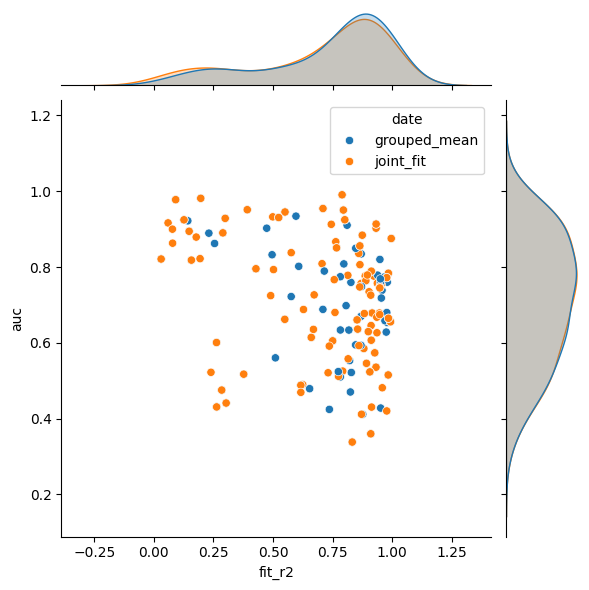

In [143]:


plot = sns.jointplot(
    data=df_joint_plot[df_joint_plot['time'] == 48],
    x='fit_r2',
    y='auc',
    hue='date'
)

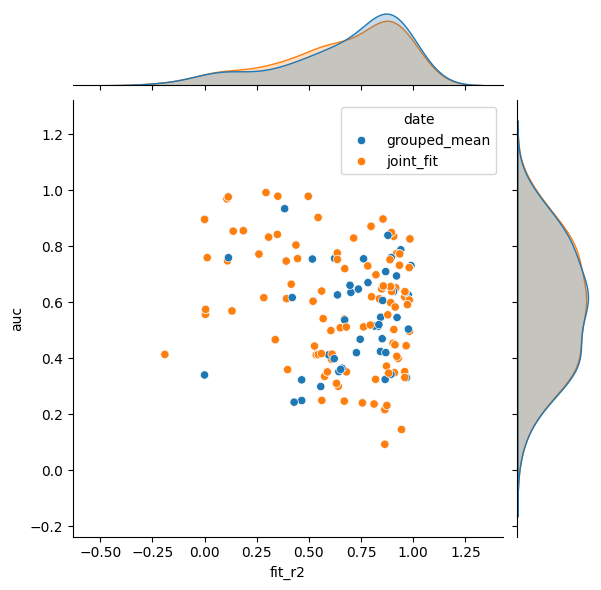

In [144]:

plot = sns.jointplot(
    data=df_joint_plot[df_joint_plot['time'] == 120],
    x='fit_r2',
    y='auc',
    hue='date'
)

Get deltas

In [177]:
df_tmp = df_joint_plot[['improve_sample_id', 'improve_drug_id', 'time', 'fit_r2', 'auc', 'date']]
df_tmp.head()

,improve_sample_id,improve_drug_id,time,fit_r2,auc,date
2,JH-2-002,RMC4630,48.0,0.91030,0.3599,grouped_mean
3,JH-2-002,RMC4630,120.0,0.86440,0.2157,grouped_mean
4,JH-2-002,RMC4630,48.0,0.91030,0.3599,joint_fit
5,JH-2-002,RMC4630,120.0,0.86440,0.2157,joint_fit
14,JH-2-002,TNO155,48.0,0.81835,0.6337,grouped_mean


In [178]:
df_tmp.pivot(
        index=['improve_sample_id', 'improve_drug_id', 'time'],
        columns='date',
        values=['fit_r2','auc']
        ).reset_index()

improve_sample_id improve_drug_id   time       fit_r2            \
date                                          grouped_mean joint_fit   
0             JH-2-002         RMC4630   48.0     0.910300    0.9103   
1             JH-2-002         RMC4630  120.0     0.864400    0.8644   
2             JH-2-002          TNO155   48.0     0.818350    0.6697   
3             JH-2-002          TNO155  120.0     0.557025    0.6409   
4             JH-2-002      capmatinib   48.0     0.230900    0.1778   
..                 ...             ...    ...          ...       ...   
194             WU-356    pexidartinib  120.0     0.838100    0.8381   
195             WU-356     trabectedin   48.0     0.950700    0.8960   
196             WU-356     trabectedin  120.0     0.853700    0.8004   
197             WU-356      vorinostat   48.0     0.653733    0.9586   
198             WU-356      vorinostat  120.0     0.893733    0.8827   

              auc            
date grouped_mean joint_fit  
0        0.359900    0.3599  
1        0.215700    0.2157  
2        0.633700    0.6355  
3        0.298250    0.2993  
4        0.889450    0.8791  
..            ...       ...  
194      0.611500    0.6115  
195      0.768850    0.7790  
196      0.605700    0.6190  
197      0.478967    0.4814  
198      0.342033    0.3462  

[199 rows x 7 columns]

In [166]:
df_delta_48 = df_tmp.groupby(['improve_sample_id', 'improve_drug_id'], as_index=True).agg(delta_r2=('fit_r2', 'diff'), delta_auc=('auc', 'diff'))

In [167]:
df_delta_48

,delta_r2,delta_auc
2,NaN,NaN
4,0.000000,0.000000
14,NaN,NaN
16,-0.148650,0.001800
22,NaN,NaN
...,...,...
739,0.000000,0.000000
745,NaN,NaN
747,-0.054700,0.010150
755,NaN,NaN
